## **Introduction**

Bitcoin is the world's first and most widely adopted cryptocurrency, known for its decentralised nature and high market volatility. Understanding its historical performance can offer insights into broader trends in the cryptocurrency space, investor behaviour, and market cycles.

This project uses a detailed dataset of historical Bitcoin market data to analyse trends, evaluate volatility, and potentially forecast future movements using basic time-series techniques.

### **Data Summary**

The dataset provides daily Bitcoin trading data, including:

Open, High, Low, and Close prices (in USD)

Volume traded (in BTC)

Date range: from 2014-09-17 to the most recent available date

### **Project Objectives**

Visualize long-term trends in Bitcoin price and volume

Calculate and interpret Bitcoin's daily returns and volatility

Identify periods of high and low volatility

Answer key financial questions based on historical patterns

Optionally apply forecasting or feature engineering (e.g., moving averages)

### **Questions to Explore**

To guide our analysis and ensure meaningful insights, we will explore the following questions:

Which day of the week yields the highest average return for Bitcoin?

Which month in Bitcoin’s history has been the most profitable?

What has been Bitcoin’s year-over-year growth rate over time?

Which year recorded the highest overall gain in Bitcoin’s closing price?

Are there any recurring seasonal patterns or anomalies in Bitcoin’s price behavior?

#### **Feature Engineering**

To enhance the model's ability to learn from price movements, we engineered several features based on price trends, volatility, and momentum:

- **Lagged Returns**: Returns from previous days (e.g., 1-day, 2-day) to capture short-term memory
- **Rolling Volatility**: Standard deviation of daily returns over recent windows (e.g., 7-day, 14-day)
- **Rolling Averages**: Moving averages of closing price to identify trend direction
- **Return vs Moving Average**: Ratio of current price to its recent average (momentum indicator)
- **Volume Change**: Percentage change in volume to highlight spikes in trading activity

These features aim to provide the model with signals that capture both short-term and trend-following behaviors.

## **Imports**

In [878]:
import pandas as pd                    # DataFrames, CSV I/O
import numpy as np
import matplotlib.pyplot as plt        # general plotting
from plotnine import ggplot, aes, geom_col, labs, theme_minimal  # Grammar‑of‑Graphics charts
from plotnine import ggplot, aes, geom_col, geom_boxplot, labs, theme_minimal

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from lazypredict.Supervised import LazyClassifier

from scipy import stats                # t‑tests and other stats functions

## **Data Dictionary**

| Column Name | Data Type              | Description                                                                                                                        |
| ----------- | ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **Date**    | `object` (date string) | The calendar date for the trading data (format: `YYYY-MM-DD`). Each row corresponds to one full trading day.                       |
| **Close**   | `float`                | The final trading price of Bitcoin at the end of the day in USD. Commonly used to assess daily performance and run trend analyses. |
| **High**    | `float`                | The highest recorded trading price during that day in USD. Useful for identifying intraday peaks and market extremes.              |
| **Low**     | `float`                | The lowest trading price of Bitcoin within the day in USD. Helps gauge downside volatility.                                        |
| **Open**    | `float`                | The price of Bitcoin at the start of the trading day in USD. Often compared with the Close for calculating daily returns.          |
| **Volume**  | `float`                | Total Bitcoin volume traded during the day (not in USD but in BTC). Indicates market activity and liquidity.                       |

#### **Terminology**

| Feature Name      | Meaning                                                                                                |
| ----------------- | ------------------------------------------------------------------------------------------------------ |
| `ret`             | **Daily return** — percentage change in closing price from the previous day                            |
| `ret_lag1`        | **Lagged return (1 day ago)** — previous day's return                                                  |
| `ret_lag2`        | **Lagged return (2 days ago)** — return from two days prior                                            |
| `vol_7d`          | **7-day rolling volatility** — standard deviation of returns over the last 7 days                      |
| `vol_14d`         | **14-day rolling volatility** — same as above, over 14 days                                            |
| `ma_7`            | **7-day moving average** — average of closing prices over the last 7 days                              |
| `ma_14`           | **14-day moving average** — average over the last 14 days                                              |
| `ret_vs_ma`       | **Return vs. moving average** — ratio of current price to its 7-day moving average (captures momentum) |
| `price_change_3d` | **3-day return** — percent change in closing price over the past 3 days                                |
| `volume_change`   | **1-day volume change** — percent change in trading volume from the previous day                       |
| `target`          | **Binary target** — 1 if the price goes up the next day, 0 otherwise                                   |


## **Loading and inspecting the Data**

In [883]:
df = pd.read_csv("C:/Users/Shahm/Downloads/Bitcoin_history_data.csv")

In [884]:
# seeing how the data looks
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.33,468.17,452.42,465.86,21056800
1,2014-09-18,424.44,456.86,413.10,456.86,34483200
2,2014-09-19,394.80,427.83,384.53,424.10,37919700
3,2014-09-20,408.90,423.30,389.88,394.67,36863600
4,2014-09-21,398.82,412.43,393.18,408.08,26580100


In [885]:
# checking the data types and if it has missing value or is it complete dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3964 entries, 0 to 3963
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3964 non-null   object 
 1   Close   3964 non-null   float64
 2   High    3964 non-null   float64
 3   Low     3964 non-null   float64
 4   Open    3964 non-null   float64
 5   Volume  3964 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 185.9+ KB


In [886]:
# double checking the datasize
df.shape

(3964, 6)

In [887]:
# checking start and end of data set
df['Date']

0       2014-09-17
1       2014-09-18
2       2014-09-19
3       2014-09-20
4       2014-09-21
           ...    
3959    2025-07-20
3960    2025-07-21
3961    2025-07-22
3962    2025-07-23
3963    2025-07-24
Name: Date, Length: 3964, dtype: object

In [888]:
# making sure null values are 0
df.isna().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [889]:
# just incase making sure there isnt duplicates
df.duplicated().sum()

0

## **code for eda but not graphical representation (just code)**

#### **SEEING WHICH YEAR MOST PROFITABLE**

In [892]:
df['Date'] = pd.to_datetime(df['Date'])

In [893]:
df['year'] = df['Date'].dt.year

In [894]:
# for each year compute first and last close
annual = (
    df
    .sort_values('Date')
    .groupby('year')['Close']
    .agg(first_close=lambda x: x.iloc[0],
         last_close =lambda x: x.iloc[-1]))

In [895]:
# compute pct growth
annual['growth_pct'] = (annual['last_close'] - annual['first_close']) \
                       / annual['first_close'] * 100

In [896]:
# show the table
print(annual)

      first_close  last_close  growth_pct
year                                     
2014       457.33      320.19      -29.99
2015       314.25      430.57       37.01
2016       434.33      963.74      121.89
2017       998.33    14156.40     1318.02
2018     13657.20     3742.70      -72.60
2019      3843.52     7193.60       87.16
2020      7200.17    29001.72      302.79
2021     29374.15    46306.45       57.64
2022     47686.81    16547.50      -65.30
2023     16625.08    42265.19      154.23
2024     44167.33    93429.20      111.53
2025     94419.76   118368.00       25.36


In [897]:
# find most profitable year
best = annual['growth_pct'].idxmax()
print(f"\nMost profitable year: {best}, growth = {annual.loc[best,'growth_pct']:.2f}%")


Most profitable year: 2017, growth = 1318.02%


In [898]:
annual_plot = annual.reset_index().rename(columns={'index':'year'})

#### **which month gave out most profit through out its history**

In [900]:
# 1. parse Date
df['Date'] = pd.to_datetime(df['Date'])

In [901]:
# 2. define year‑month period
df['ym'] = df['Date'].dt.to_period('M')

In [902]:
# 3. for each month period get first and last Close
monthly = (
    df
    .sort_values('Date')
    .groupby('ym')['Close']
    .agg(
        first_close = lambda x: x.iloc[0],
        last_close  = lambda x: x.iloc[-1]
    )
)

In [903]:
# 4. compute pct growth
monthly['growth_pct'] = (
    (monthly['last_close'] - monthly['first_close'])
    / monthly['first_close'] * 100
)

In [904]:
# 5. extract calendar month as integer 1–12
monthly['month'] = monthly.index.month

In [905]:
# 6. average growth by calendar month
avg_by_month = monthly.groupby('month')['growth_pct'].mean()

In [906]:
# 7. identify best month
best = avg_by_month.idxmax()
best_val = avg_by_month.loc[best]

In [907]:
print("Average growth by month:")
print(avg_by_month)
print(f"\nBest month: {best:02d}, avg growth = {best_val:.2f}%")

Average growth by month:
month
1    -1.50
2    12.15
3    -2.31
4     9.28
5     8.51
6     1.55
7    10.53
8     1.55
9    -4.39
10   17.30
11    8.68
12    7.56
Name: growth_pct, dtype: float64

Best month: 10, avg growth = 17.30%


In [908]:
monthly_plot = monthly.reset_index()

#### **day of the week is most profitable**

In [910]:
# 1 parse Date and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

In [911]:
# 2 compute daily pct return
df['ret'] = df['Close'].pct_change() * 100

In [912]:
# 4 get weekday name
df['weekday'] = df.index.day_name()

In [913]:
# 5 average return by weekday
avg_weekday = (
    df
    .groupby('weekday')['ret']
    .mean()
    # reorder to Mon–Sun
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)

In [914]:
print("Average daily return by weekday (%)")
print(avg_weekday)

Average daily return by weekday (%)
weekday
Monday      0.52
Tuesday     0.10
Wednesday   0.27
Thursday    0.07
Friday      0.24
Saturday    0.20
Sunday      0.05
Name: ret, dtype: float64


In [915]:
# 6 identify best weekday
best_day = avg_weekday.idxmax()
best_val = avg_weekday.max()
print(f"\nMost profitable weekday: {best_day}, avg return = {best_val:.2f}%")


Most profitable weekday: Monday, avg return = 0.52%


In [916]:
# prepare DataFrame for plotting
weekday_plot = (
    avg_weekday
    .reset_index()
    .rename(columns={'ret':'avg_ret'})
)

In [917]:
# ensure correct order Mon–Sun
weekday_plot['weekday'] = pd.Categorical(
    weekday_plot['weekday'],
    categories=[
      'Monday','Tuesday','Wednesday',
      'Thursday','Friday','Saturday','Sunday'
    ],
    ordered=True
)

#### **Bitcoin Hit Rate by Weekday**

In [919]:
#  parse Date and sort
df = df.copy()
df.index = pd.to_datetime(df.index)

In [920]:
#  Compute daily pct return
df['ret'] = df['Close'].pct_change() * 100


In [921]:
#  Extract weekday name
df['weekday'] = df.index.day_name()

In [922]:
#  Flag positive‑return days
df['positive'] = df['ret'] > 0


In [923]:
#  Compute hit rate (%) by weekday
hit_rate = df.groupby('weekday')['positive'].mean() * 100

In [924]:
#  Reorder to Mon–Sun
ordered = [
  'Monday','Tuesday','Wednesday',
  'Thursday','Friday','Saturday','Sunday'
]
hit_rate = hit_rate.reindex(ordered)

In [925]:
#  Prepare for plotting
hit_plot = hit_rate.reset_index().rename(columns={'positive':'hit_rate'})
hit_plot['weekday'] = pd.Categorical(
    hit_plot['weekday'],
    categories=ordered,
    ordered=True
)

#### **How Often Each Weekday Had a Positive Average Return**

In [927]:
# 1. compute average return by year and weekday
avg_yr_wd = (
    df['ret']
    .groupby([df.index.year, df['weekday']])
    .mean()
    .unstack()  # rows = year, cols = weekday
)

In [928]:
# 2. flag positive years and sum across years
pos_counts = (avg_yr_wd > 0).sum()  # Series indexed by weekday

In [929]:
# 3. prepare for plotting
ordered = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plot_df = (
    pos_counts
    .reindex(ordered)
    .reset_index()
    .rename(columns={0:'n_years_positive', 'index':'weekday'})
)
plot_df['weekday'] = pd.Categorical(
    plot_df['weekday'],
    categories=ordered,
    ordered=True
)


## **Feature engineering**

In [1042]:
df['SMA_7'] = df['Close'].rolling(window=7).mean()
df[['Close','SMA_7']].head(10)

,Close,SMA_7
Date,,
2014-09-17,457.33,NaN
2014-09-18,424.44,NaN
2014-09-19,394.80,NaN
2014-09-20,408.90,NaN
2014-09-21,398.82,NaN
2014-09-22,402.15,NaN
2014-09-23,435.79,417.46
2014-09-24,423.20,412.59
2014-09-25,411.57,410.75


In [1048]:
df = df.dropna(subset=['SMA_7', 'target'])


In [1050]:
df[['SMA_7','target']].isna().sum()


SMA_7     0
target    0
dtype: int64

## **Exploratory Data Analysis**

#### **SEEING WHICH YEAR MOST PROFITABLE**

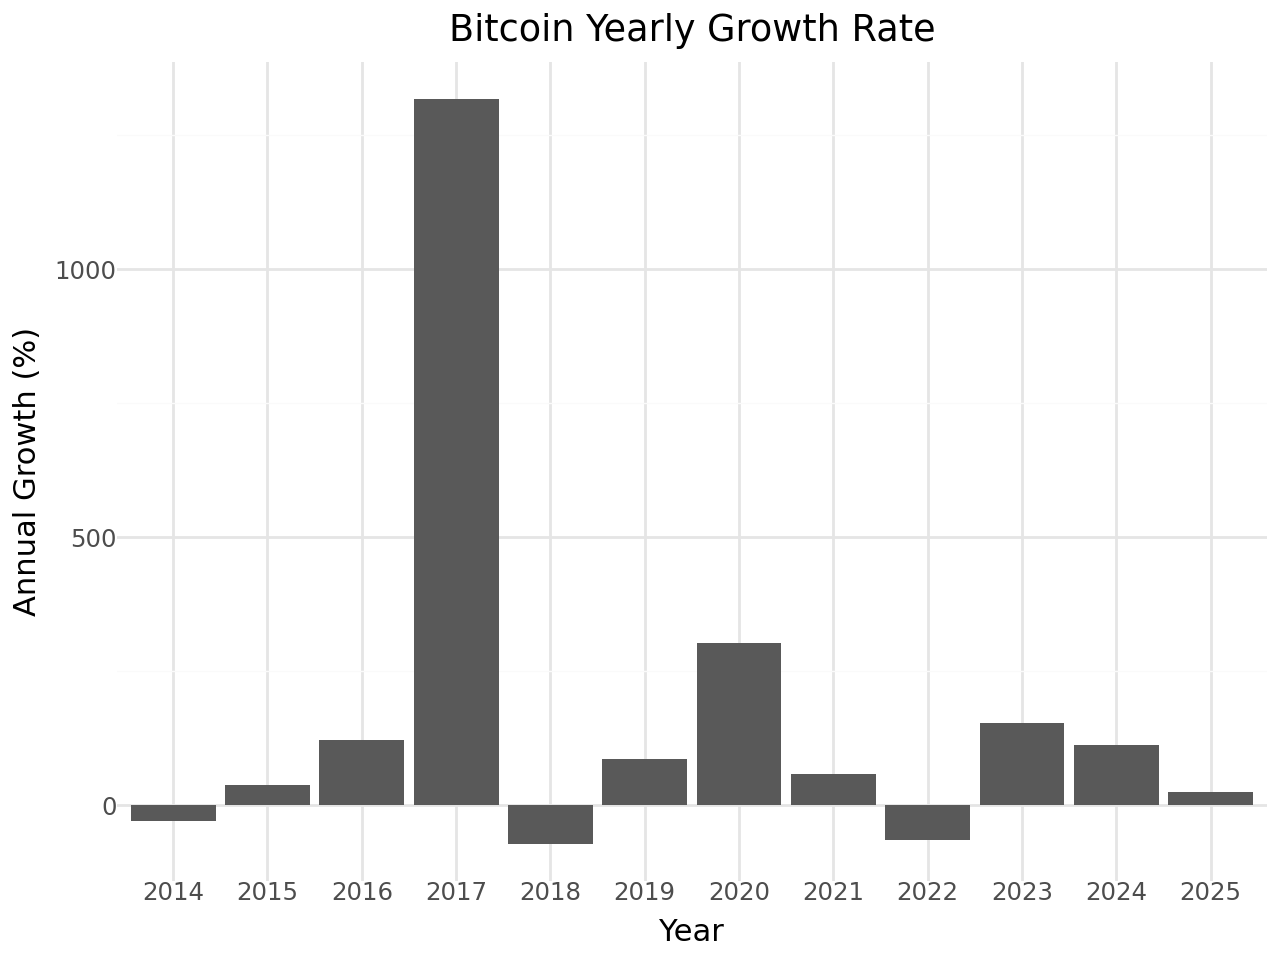

In [947]:
# bar chart
p1 = (
    ggplot(annual_plot, aes(x='factor(year)', y='growth_pct'))
  + geom_col()
  + labs(x='Year', y='Annual Growth (%)', title='Bitcoin Yearly Growth Rate')
  + theme_minimal()
)

p1

#### **growth rate yearly comparasion**

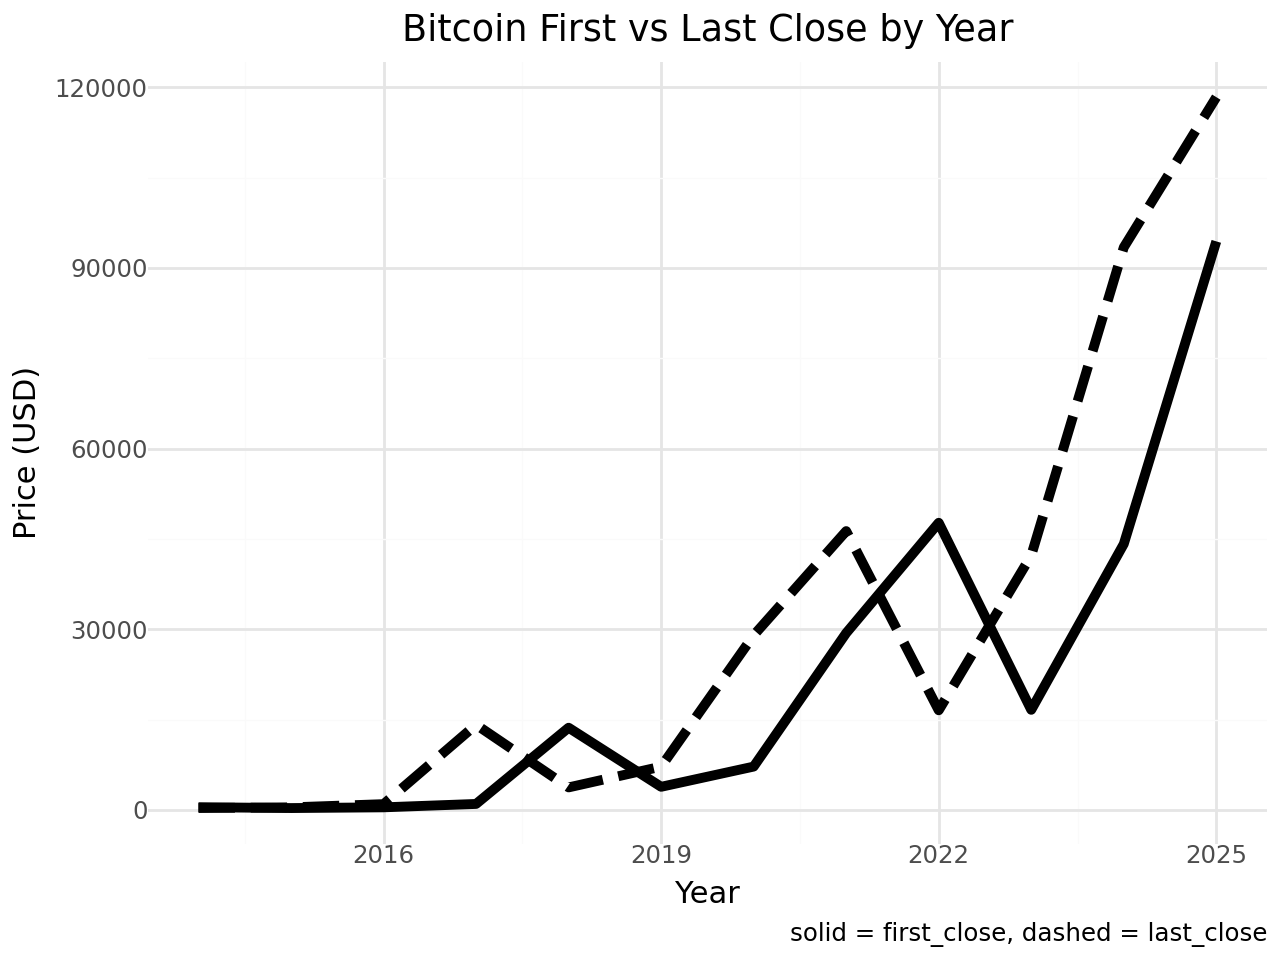

In [949]:
from plotnine import (
    ggplot, aes,
    geom_col, geom_line,    # ← add geom_line here
    labs, theme_minimal
)

p2 = (
    ggplot(annual_plot, aes(x='year'))
  + geom_line(aes(y='first_close'), size=2)
  + geom_line(aes(y='last_close'), size=2, linetype='dashed')
  + labs(
        x='Year',
        y='Price (USD)',
        title='Bitcoin First vs Last Close by Year',
        caption='solid = first_close, dashed = last_close'
    )
  + theme_minimal()
)

p2

#### **which month gave out most profit through out its history**

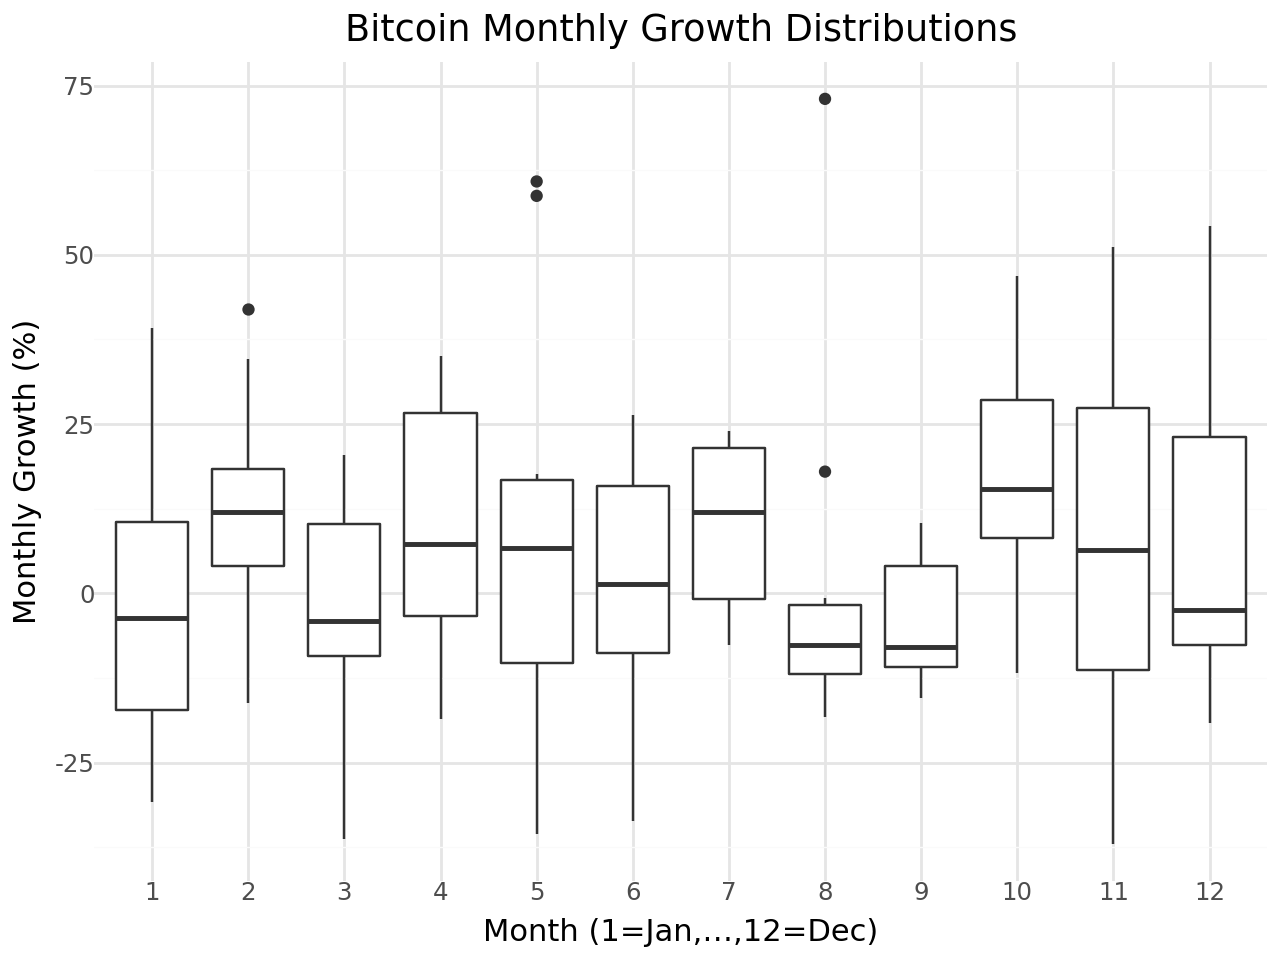

In [951]:
p3 = (
    ggplot(monthly_plot, aes(x='factor(month)', y='growth_pct'))
  + geom_boxplot(outlier_shape='o')
  + labs(
        x='Month (1=Jan,…,12=Dec)',
        y='Monthly Growth (%)',
        title='Bitcoin Monthly Growth Distributions'
    )
  + theme_minimal()
)

p3

#### **day of the week is most profitable**

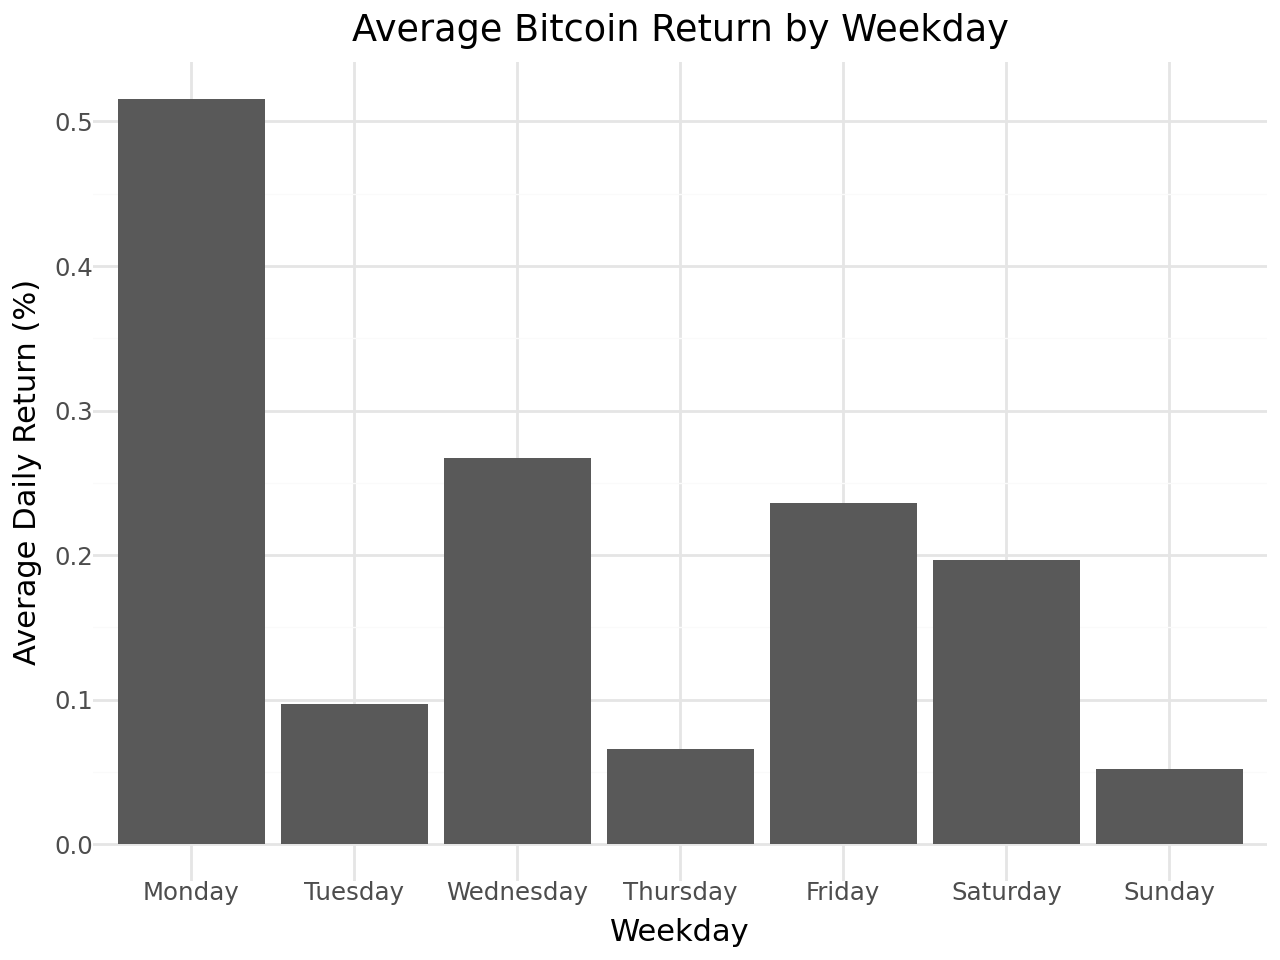

In [953]:
# bar chart
p5 = (
    ggplot(weekday_plot, aes(x='weekday', y='avg_ret'))
  + geom_col()
  + labs(
        x='Weekday',
        y='Average Daily Return (%)',
        title='Average Bitcoin Return by Weekday'
    )
  + theme_minimal()
)

p5

#### **Bitcoin Hit Rate by Weekday**

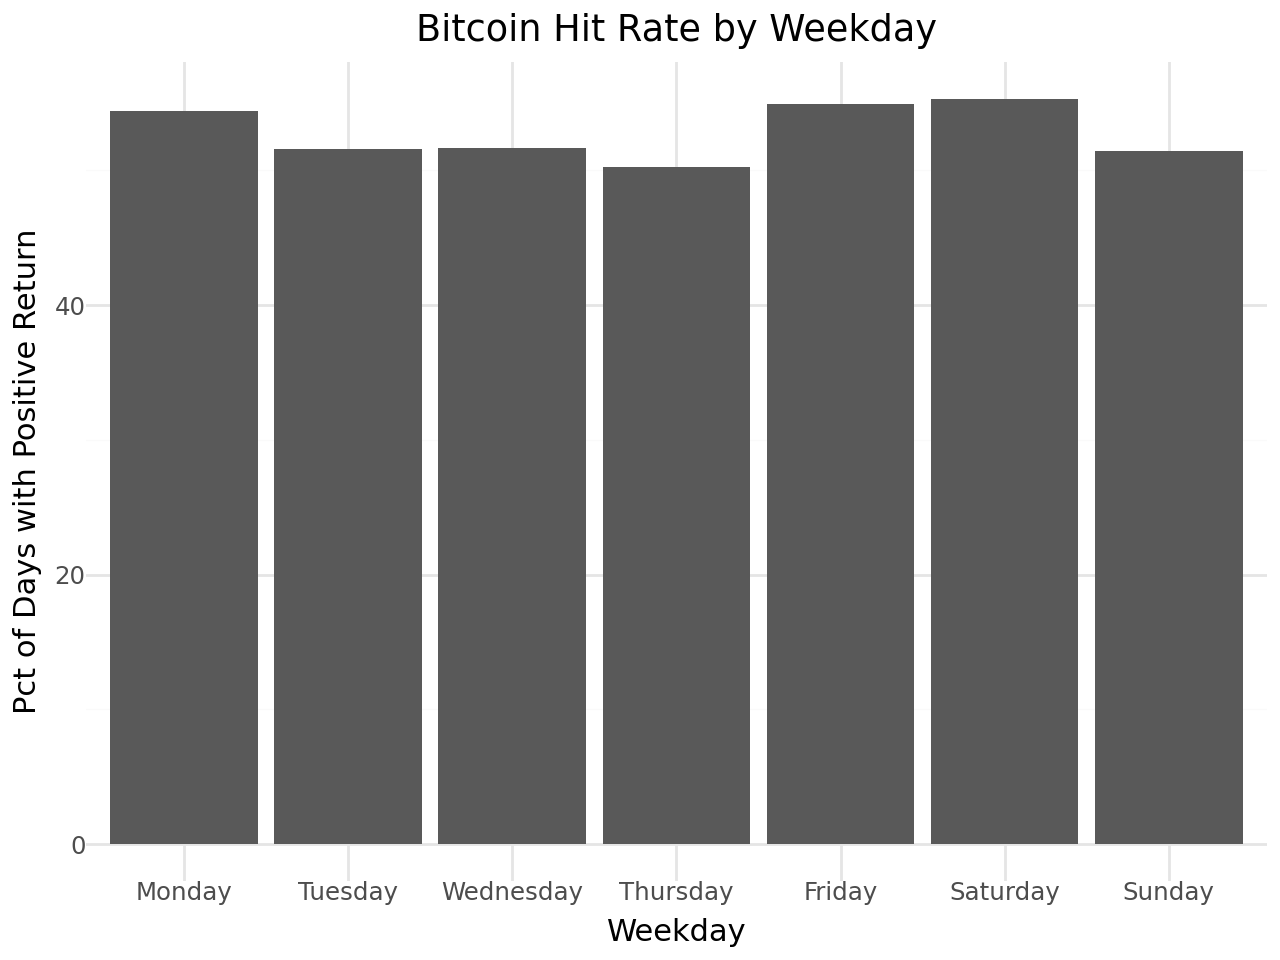

In [955]:
# 10 Draw the bar chart
p6 = (
    ggplot(hit_plot, aes(x='weekday', y='hit_rate'))
  + geom_col()
  + labs(
        x='Weekday',
        y='Pct of Days with Positive Return',
        title='Bitcoin Hit Rate by Weekday'
    )
  + theme_minimal()
)

p6


#### **How Often Each Weekday Had a Positive Average Return**

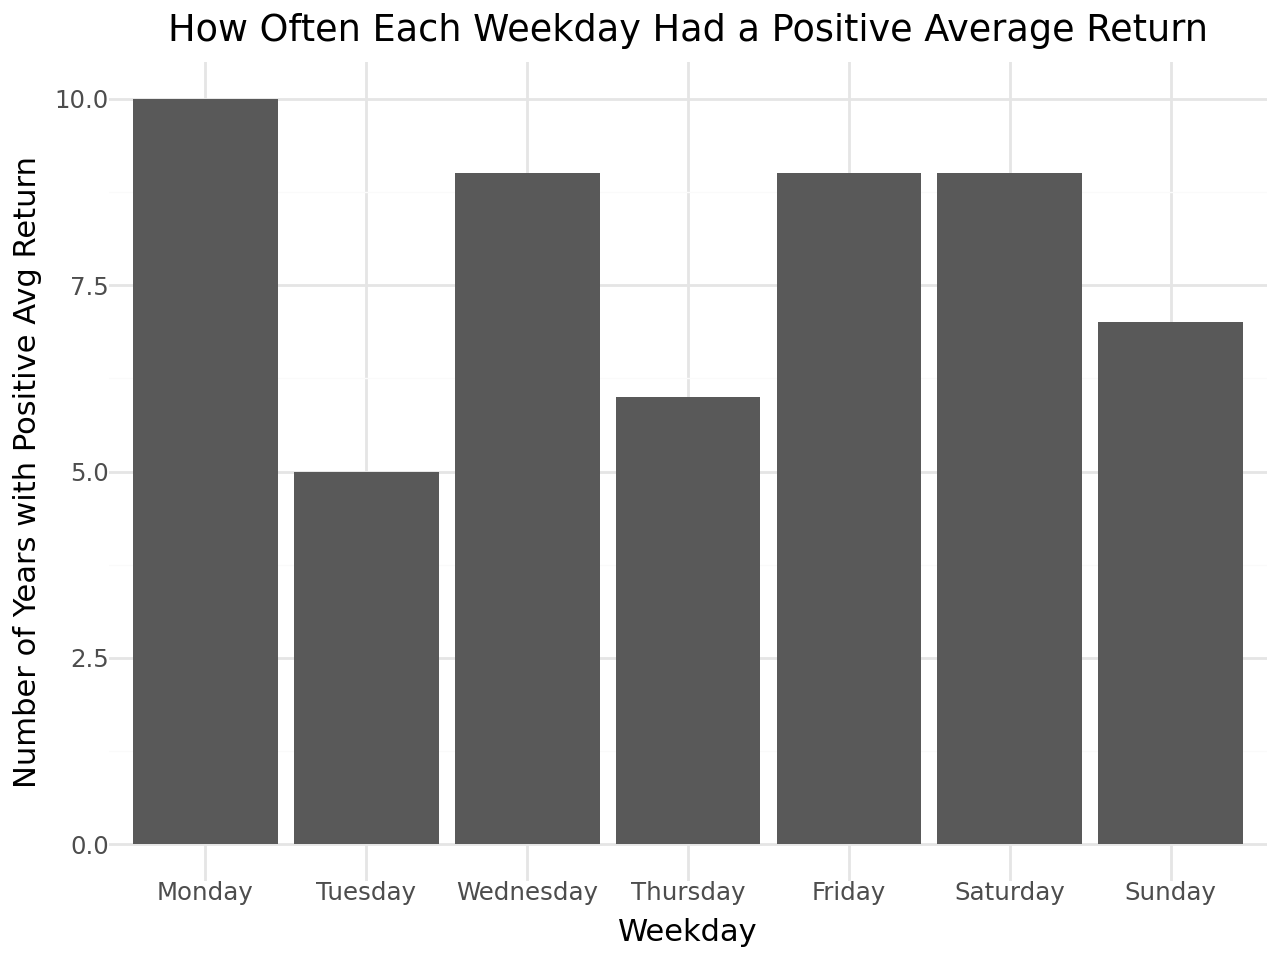

In [957]:
# 4. bar chart of count of years with positive avg return
p7 = (
    ggplot(plot_df, aes(x='weekday', y='n_years_positive'))
  + geom_col()
  + labs(
        x='Weekday',
        y='Number of Years with Positive Avg Return',
        title='How Often Each Weekday Had a Positive Average Return'
    )
  + theme_minimal()
)

p7


## **tables**

In [959]:
# 8 Print the numbers
print("Hit rate (%) by weekday")
print(hit_rate)

Hit rate (%) by weekday
weekday
Monday      54.42
Tuesday     51.59
Wednesday   51.68
Thursday    50.26
Friday      54.95
Saturday    55.30
Sunday      51.41
Name: positive, dtype: float64


In [960]:
print("Number of positive‑return days by weekday")
print(counts)


Number of positive‑return days by weekday
weekday
Monday       308
Tuesday      292
Wednesday    293
Thursday     285
Friday       311
Saturday     313
Sunday       291
Name: positive, dtype: int64


In [961]:
print("Number of negative‑return days by weekday")
print(neg_counts)


Number of negative‑return days by weekday
weekday
Monday       258
Tuesday      273
Wednesday    273
Thursday     282
Friday       255
Saturday     253
Sunday       275
Name: negative, dtype: int64


## **Machine Learning**

#### **Train-Test Split**

In [1044]:
df['target'] = df['Close'].shift(-1) > df['Open'].shift(-1)

In [1056]:
df.head(10)

,Close,High,Low,Open,Volume,year,ym,ret,weekday,positive,SMA_7,target
Date,,,,,,,,,,,,
2014-09-23,435.79,441.56,396.20,402.09,45099500,2014,2014-09,8.36,Tuesday,True,417.46,False
2014-09-24,423.20,436.11,421.13,435.75,30627700,2014,2014-09,-2.89,Wednesday,False,412.59,False
2014-09-25,411.57,423.52,409.47,423.16,26814400,2014,2014-09,-2.75,Thursday,False,410.75,False
2014-09-26,404.42,414.94,400.01,411.43,21460800,2014,2014-09,-1.74,Friday,False,412.12,False
2014-09-27,399.52,406.62,397.37,403.56,15029300,2014,2014-09,-1.21,Saturday,False,410.78,False
2014-09-28,377.18,401.02,374.33,399.47,23613300,2014,2014-09,-5.59,Sunday,False,407.69,False
2014-09-29,375.47,385.21,372.24,376.93,32497700,2014,2014-09,-0.45,Monday,False,403.88,True
2014-09-30,386.94,390.98,373.44,376.09,34707300,2014,2014-09,3.06,Tuesday,True,396.90,False
2014-10-01,383.61,391.38,380.78,387.43,26229400,2014,2014-10,-0.86,Wednesday,False,391.25,False


In [1052]:
# 1. Features and target
X = df[['SMA_7']]
y = df['target']

# 2. Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42  # for reproducibility
)

In [1054]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3166, 1) (792, 1) (3166,) (792,)


In [1058]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate
clf = DecisionTreeClassifier(random_state=42)

# 2. Fit
clf.fit(X_train, y_train)

# 3. Predict
y_pred = clf.predict(X_test)

# 4. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.5126262626262627

Classification Report:
               precision    recall  f1-score   support

       False       0.50      0.49      0.49       384
        True       0.53      0.54      0.53       408

    accuracy                           0.51       792
   macro avg       0.51      0.51      0.51       792
weighted avg       0.51      0.51      0.51       792


Confusion Matrix:
 [[187 197]
 [189 219]]


In [1060]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for max_depth
param_grid = {'max_depth': [3, 5, 7, None]}

# Grid search with 5‑fold CV
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Fit on the training data
grid.fit(X_train, y_train)

# Show the best depth and corresponding score
print("Best max_depth:", grid.best_params_['max_depth'])
print("Best CV accuracy:", grid.best_score_)


Best max_depth: 3
Best CV accuracy: 0.5255854401204021


In [1062]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


Best params: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV accuracy: 0.5259013958865948


In [1064]:
# 1. Instantiate tuned classifier
tuned_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=42
)

# 2. Fit on the full training data
tuned_clf.fit(X_train, y_train)

# 3. Predict on the test set
y_tuned_pred = tuned_clf.predict(X_test)

# 4. Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_tuned_pred))
print("\nClassification Report:\n", classification_report(y_test, y_tuned_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_tuned_pred))


Test Accuracy: 0.494949494949495

Classification Report:
               precision    recall  f1-score   support

       False       0.33      0.04      0.07       384
        True       0.51      0.92      0.65       408

    accuracy                           0.49       792
   macro avg       0.42      0.48      0.36       792
weighted avg       0.42      0.49      0.37       792


Confusion Matrix:
 [[ 16 368]
 [ 32 376]]


### **Compute the 21‑day SMA**

In [1067]:
df['SMA_21'] = df['Close'].rolling(window=21).mean()

In [1069]:
df[['Close','SMA_7','SMA_21']].head(25)

,Close,SMA_7,SMA_21
Date,,,
2014-09-23,435.79,417.46,NaN
2014-09-24,423.20,412.59,NaN
2014-09-25,411.57,410.75,NaN
2014-09-26,404.42,412.12,NaN
2014-09-27,399.52,410.78,NaN
2014-09-28,377.18,407.69,NaN
2014-09-29,375.47,403.88,NaN
2014-09-30,386.94,396.90,NaN
2014-10-01,383.61,391.25,NaN


In [1071]:
df = df.dropna(subset=['SMA_7','SMA_21','target'])

In [1075]:
df[['SMA_7','SMA_21','target']].isna().sum()

SMA_7     0
SMA_21    0
target    0
dtype: int64

In [1073]:
X = df[['SMA_7','SMA_21']]

In [1079]:
# 1. New features
X = df[['SMA_7','SMA_21']]
y = df['target']

# 2. Resplit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Check shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3150, 2) (788, 2) (3150,) (788,)


In [1081]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate the tuned classifier
tuned_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=42
)

# 2. Fit on the new training set
tuned_clf.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = tuned_clf.predict(X_test)

# 4. Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.5139593908629442

Classification Report:
               precision    recall  f1-score   support

       False       0.39      0.05      0.09       373
        True       0.52      0.93      0.67       415

    accuracy                           0.51       788
   macro avg       0.46      0.49      0.38       788
weighted avg       0.46      0.51      0.39       788


Confusion Matrix:
 [[ 18 355]
 [ 28 387]]


### **Relative Strength Index (RSI)**

In [1084]:
df['delta'] = df['Close'].diff()


In [1086]:
df['delta'].head(15)

Date
2014-10-13      NaN
2014-10-14    10.46
2014-10-15    -6.10
2014-10-16   -12.22
2014-10-17     1.20
2014-10-18     7.68
2014-10-19    -1.90
2014-10-20    -6.70
2014-10-21     3.63
2014-10-22    -3.32
2014-10-23   -24.74
2014-10-24    -0.07
2014-10-25   -11.07
2014-10-26     7.43
2014-10-27    -1.71
Name: delta, dtype: float64

In [1090]:
df['gain'] = df['delta'].clip(lower=0)
df['loss'] = (-df['delta']).clip(lower=0)

In [1092]:
df[['delta','gain','loss']].head(15)

,delta,gain,loss
Date,,,
2014-10-13,NaN,NaN,NaN
2014-10-14,10.46,10.46,0.00
2014-10-15,-6.10,0.00,6.10
2014-10-16,-12.22,0.00,12.22
2014-10-17,1.20,1.20,0.00
2014-10-18,7.68,7.68,0.00
2014-10-19,-1.90,0.00,1.90
2014-10-20,-6.70,0.00,6.70
2014-10-21,3.63,3.63,0.00


In [1094]:
# rolling average of gains and losses over 14 days
df['avg_gain'] = df['gain'].rolling(window=14, min_periods=14).mean()
df['avg_loss'] = df['loss'].rolling(window=14, min_periods=14).mean()

# relative strength and RSI
df['RS']     = df['avg_gain'] / df['avg_loss']
df['RSI_14'] = 100 - (100 / (1 + df['RS']))

In [1096]:
df[['gain','loss','avg_gain','avg_loss','RS','RSI_14']].head(20)

,gain,loss,avg_gain,avg_loss,RS,RSI_14
Date,,,,,,
2014-10-13,NaN,NaN,NaN,NaN,NaN,NaN
2014-10-14,10.46,0.00,NaN,NaN,NaN,NaN
2014-10-15,0.00,6.10,NaN,NaN,NaN,NaN
2014-10-16,0.00,12.22,NaN,NaN,NaN,NaN
2014-10-17,1.20,0.00,NaN,NaN,NaN,NaN
2014-10-18,7.68,0.00,NaN,NaN,NaN,NaN
2014-10-19,0.00,1.90,NaN,NaN,NaN,NaN
2014-10-20,0.00,6.70,NaN,NaN,NaN,NaN
2014-10-21,3.63,0.00,NaN,NaN,NaN,NaN


In [1098]:
df = df.dropna(subset=['SMA_7','SMA_21','RSI_14','target'])

In [1100]:
df[['SMA_7','SMA_21','RSI_14','target']].isna().sum()

SMA_7     0
SMA_21    0
RSI_14    0
target    0
dtype: int64

In [1102]:
# 1. Define X and y with all three features
X = df[['SMA_7', 'SMA_21', 'RSI_14']]
y = df['target']

# 2. Resplit into 80/20 train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Check shapes to confirm
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# 4. Retrain the tuned classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tuned_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=42
)
tuned_clf.fit(X_train, y_train)
y_pred = tuned_clf.predict(X_test)

# 5. Evaluate performance
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


(3139, 3) (785, 3) (3139,) (785,)
Test Accuracy: 0.5197452229299363

Classification Report:
               precision    recall  f1-score   support

       False       0.46      0.45      0.45       347
        True       0.57      0.58      0.57       438

    accuracy                           0.52       785
   macro avg       0.51      0.51      0.51       785
weighted avg       0.52      0.52      0.52       785


Confusion Matrix:
 [[155 192]
 [185 253]]


In [1114]:
from sklearn.metrics import roc_curve, auc

# 1. Get predicted probabilities for the “up” class
y_proba = tuned_clf.predict_proba(X_test)[:, 1]

# 2. Compute false‑ and true‑positive rates
fpr, tpr, _ = roc_curve(y_test, y_proba)

# 3. Compute the area under the curve
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)


ROC AUC: 0.5141328806600608


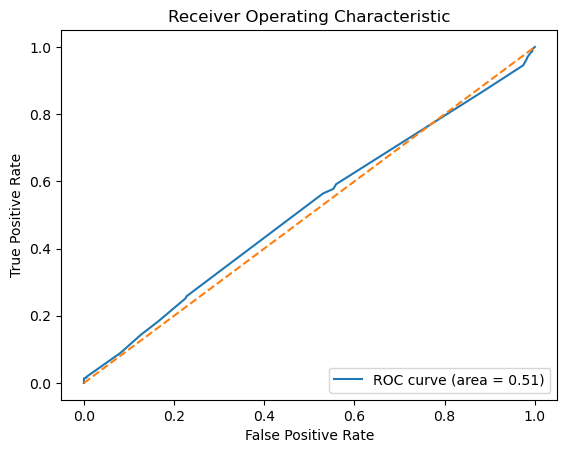

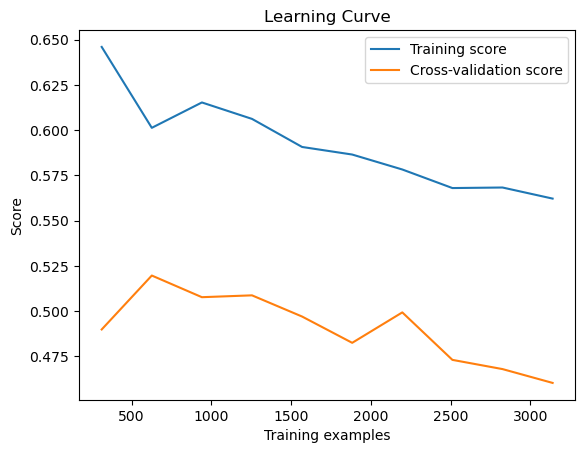

In [1116]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# ---- ROC Curve ----
y_proba = tuned_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# ---- Learning Curve ----
train_sizes, train_scores, test_scores = learning_curve(
    tuned_clf, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()


In [1118]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate XGBoost classifier
xgb_clf = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Fit on training data
xgb_clf.fit(X_train, y_train)

# 3. Predict on test set
y_xgb_pred = xgb_clf.predict(X_test)

# 4. Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, y_xgb_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_xgb_pred))


Test Accuracy: 0.5210191082802548

Classification Report:
               precision    recall  f1-score   support

       False       0.46      0.52      0.49       347
        True       0.58      0.52      0.55       438

    accuracy                           0.52       785
   macro avg       0.52      0.52      0.52       785
weighted avg       0.53      0.52      0.52       785


Confusion Matrix:
 [[181 166]
 [210 228]]


In [1125]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st

# 1. Build a pipeline with a single step named “clf”
pipeline = Pipeline([
    ('clf', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# 2. Define your distribution, but prefix every param with “clf__”
param_dist = {
    'clf__n_estimators':     st.randint(50, 500),
    'clf__max_depth':        st.randint(3, 10),
    'clf__learning_rate':    st.loguniform(0.01, 0.2),
    'clf__subsample':        st.uniform(0.6, 0.4),
    'clf__colsample_bytree': st.uniform(0.6, 0.4),
    'clf__gamma':            st.uniform(0, 5)
}

# 3. Set up RandomizedSearchCV on the pipeline
rand_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# 4. Fit on your training data
rand_search.fit(X_train, y_train)

# 5. Inspect the best params and score
print("Best params:", rand_search.best_params_)
print("Best CV accuracy:", rand_search.best_score_)

Best params: {'clf__colsample_bytree': 0.749816047538945, 'clf__gamma': 4.75357153204958, 'clf__learning_rate': 0.08960785365368121, 'clf__max_depth': 7, 'clf__n_estimators': 70, 'clf__subsample': 0.6624074561769746}
Best CV accuracy: nan


In [1129]:
best_params = rand_search.best_params_
# Remove the pipeline prefix
xgb_params = {k.replace('clf__',''): v for k, v in best_params.items()}
print(xgb_params)


{'colsample_bytree': 0.749816047538945, 'gamma': 4.75357153204958, 'learning_rate': 0.08960785365368121, 'max_depth': 7, 'n_estimators': 70, 'subsample': 0.6624074561769746}


In [1133]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate with the tuned params
xgb_tuned = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    colsample_bytree=0.749816047538945,
    gamma=4.75357153204958,
    learning_rate=0.08960785365368121,
    max_depth=7,
    n_estimators=70,
    subsample=0.6624074561769746
)

# 2. Fit on the training set
xgb_tuned.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = xgb_tuned.predict(X_test)

# 4. Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5312101910828025

Classification Report:
               precision    recall  f1-score   support

       False       0.46      0.39      0.43       347
        True       0.57      0.64      0.60       438

    accuracy                           0.53       785
   macro avg       0.52      0.52      0.52       785
weighted avg       0.52      0.53      0.53       785


Confusion Matrix:
 [[137 210]
 [158 280]]


In [1137]:
# Create a Series of feature importances
feat_importances = pd.Series(
    xgb_tuned.feature_importances_, index=X_train.columns
)

# Sort and print
print(feat_importances.sort_values())

SMA_7    0.32
SMA_21   0.33
RSI_14   0.35
dtype: float32


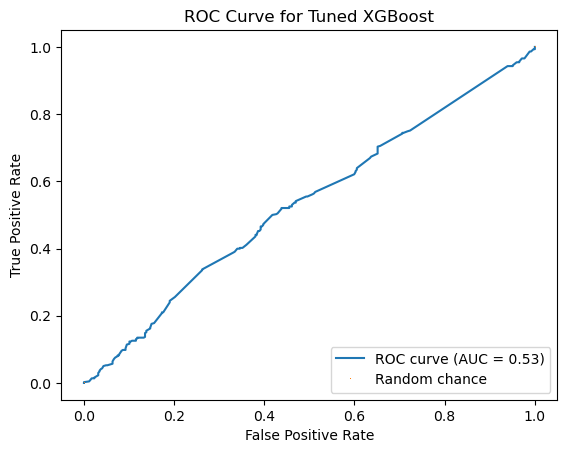

In [1139]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the “up” class
y_proba = xgb_tuned.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], ',', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned XGBoost')
plt.legend(loc='lower right')
plt.show()
